<a href="https://colab.research.google.com/github/Hotl77/NIR_Code/blob/main/KerasCode.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Импорты

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import json
import random
import numpy as np
import tensorflow as tf
from math import ceil
from tqdm import tqdm
import imageio.v2 as imageio
from scipy.ndimage import zoom
from pandas import read_csv
from tensorflow.keras.callbacks import ModelCheckpoint, CSVLogger, LearningRateScheduler
from tensorflow.keras import layers, Model
import gc
from skimage.transform import AffineTransform, warp

try:
    import keras_tuner as kt
except ImportError:
    %pip install -q keras-tuner
    import keras_tuner as kt

NORMALISE_IMGS = True
DATA_AUG = True
PATCH_SIDE = 96
TYPE = 3                     # 0-RGB | 1-RGBIr | 2-All bands <=20m | 3-All bands
TRAIN_STRIDE = 47

BATCH_SIZE = 32
N_EPOCHS = 100
LEARNING_RATE = 0.001
FP_MODIFIER = 10
PATH_TO_DATASET = '/content/drive/MyDrive/НИР/Onera/Onera Satellite Change Detection dataset - Images/Onera Satellite Change Detection dataset - Images/'
save_dir = '/content/drive/MyDrive/НИР/Гитхаб/alltrash/keras/'
path_to_test_dir1 = '/content/drive/MyDrive/НИР/GLaD4CD/'
path_to_test_dir2 = '/content/drive/MyDrive/НИР/Sentinel-2 Multitemporal Cities Pairs/'

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 4.3 MB/s eta 0:00:00


# Датасет

In [ ]:
class Load_Dataset(object):

    @staticmethod
    def adjust_shape(I, s):
        """Adjust shape of grayscale image I to s."""

        # crop if necesary
        I = I[:s[0],:s[1]]
        si = I.shape

        # pad if necessary
        p0 = max(0,s[0] - si[0])
        p1 = max(0,s[1] - si[1])

        return np.pad(I,((0,p0),(0,p1)),'edge')


    @staticmethod
    def read_sentinel_img(path):
        """Read cropped Sentinel-2 image: RGB bands."""
        im_name = os.listdir(path)[0][:-7]
        r = imageio.imread(path + im_name + "B04.tif")
        g = imageio.imread(path + im_name + "B03.tif")
        b = imageio.imread(path + im_name + "B02.tif")

        I = np.stack((r,g,b),axis=2).astype('float32')

        if NORMALISE_IMGS:
            I = (I - I.mean()) / I.std()

        return I

    @staticmethod
    def read_sentinel_img_4(path):
        """Read cropped Sentinel-2 image: RGB and NIR bands."""
        im_name = os.listdir(path)[0][:-7]
        r = imageio.imread(path + im_name + "B04.tif")
        g = imageio.imread(path + im_name + "B03.tif")
        b = imageio.imread(path + im_name + "B02.tif")
        nir = imageio.imread(path + im_name + "B08.tif")

        I = np.stack((r,g,b,nir),axis=2).astype('float32')

        if NORMALISE_IMGS:
            I = (I - I.mean()) / I.std()

        return I

    @staticmethod
    def read_sentinel_img_leq20(path):
        """Read cropped Sentinel-2 image: bands with resolution less than or equals to 20m."""
        im_name = os.listdir(path)[0][:-7]

        r = imageio.imread(path + im_name + "B04.tif")
        s = r.shape
        g = imageio.imread(path + im_name + "B03.tif")
        b = imageio.imread(path + im_name + "B02.tif")
        nir = imageio.imread(path + im_name + "B08.tif")

        ir1 = Load_Dataset.adjust_shape(zoom(imageio.imread(path + im_name + "B05.tif"),2),s)
        ir2 = Load_Dataset.adjust_shape(zoom(imageio.imread(path + im_name + "B06.tif"),2),s)
        ir3 = Load_Dataset.adjust_shape(zoom(imageio.imread(path + im_name + "B07.tif"),2),s)
        nir2 = Load_Dataset.adjust_shape(zoom(imageio.imread(path + im_name + "B8A.tif"),2),s)
        swir2 = Load_Dataset.adjust_shape(zoom(imageio.imread(path + im_name + "B11.tif"),2),s)
        swir3 = Load_Dataset.adjust_shape(zoom(imageio.imread(path + im_name + "B12.tif"),2),s)

        I = np.stack((r,g,b,nir,ir1,ir2,ir3,nir2,swir2,swir3),axis=2).astype('float32')

        if NORMALISE_IMGS:
            I = (I - I.mean()) / I.std()

        return I

    @staticmethod
    def read_sentinel_img_leq60(path):
        """Read cropped Sentinel-2 image: all bands."""
        im_name = os.listdir(path)[0][:-7]

        r = imageio.imread(path + im_name + "B04.tif")
        s = r.shape
        g = imageio.imread(path + im_name + "B03.tif")
        b = imageio.imread(path + im_name + "B02.tif")
        nir = imageio.imread(path + im_name + "B08.tif")

        ir1 = Load_Dataset.adjust_shape(zoom(imageio.imread(path + im_name + "B05.tif"),2),s)
        ir2 = Load_Dataset.adjust_shape(zoom(imageio.imread(path + im_name + "B06.tif"),2),s)
        ir3 = Load_Dataset.adjust_shape(zoom(imageio.imread(path + im_name + "B07.tif"),2),s)
        nir2 = Load_Dataset.adjust_shape(zoom(imageio.imread(path + im_name + "B8A.tif"),2),s)
        swir2 = Load_Dataset.adjust_shape(zoom(imageio.imread(path + im_name + "B11.tif"),2),s)
        swir3 = Load_Dataset.adjust_shape(zoom(imageio.imread(path + im_name + "B12.tif"),2),s)

        uv = Load_Dataset.adjust_shape(zoom(imageio.imread(path + im_name + "B01.tif"),6),s)
        wv = Load_Dataset.adjust_shape(zoom(imageio.imread(path + im_name + "B09.tif"),6),s)
        swirc = Load_Dataset.adjust_shape(zoom(imageio.imread(path + im_name + "B10.tif"),6),s)

        I = np.stack((r,g,b,nir,ir1,ir2,ir3,nir2,swir2,swir3,uv,wv,swirc),axis=2).astype('float32')

        if NORMALISE_IMGS:
            I = (I - I.mean()) / I.std()

        return I

    @staticmethod
    def read_sentinel_img_trio(path):
        """Read cropped Sentinel-2 image pair and change map."""
    #     read images
        if TYPE == 0:
            I1 = Load_Dataset.read_sentinel_img(path + '/imgs_1/')
            I2 = Load_Dataset.read_sentinel_img(path + '/imgs_2/')
        elif TYPE == 1:
            I1 = Load_Dataset.read_sentinel_img_4(path + '/imgs_1/')
            I2 = Load_Dataset.read_sentinel_img_4(path + '/imgs_2/')
        elif TYPE == 2:
            I1 = Load_Dataset.read_sentinel_img_leq20(path + '/imgs_1/')
            I2 = Load_Dataset.read_sentinel_img_leq20(path + '/imgs_2/')
        elif TYPE == 3:
            I1 = Load_Dataset.read_sentinel_img_leq60(path + '/imgs_1/')
            I2 = Load_Dataset.read_sentinel_img_leq60(path + '/imgs_2/')

        cm = imageio.imread(path + '/cm/cm.png', mode='L') != 0  #белый цвет - 255, будет true; черный цвет - 0, будет false

        # crop if necessary
        s1 = I1.shape
        s2 = I2.shape
        if s1[:2] != s2[:2]:
            I2 = np.pad(I2,((0, s1[0] - s2[0]), (0, s1[1] - s2[1]), (0,0)),'edge')


        return I1, I2, cm




class DataAugmentation:

    def __call__(self, I1, I2, label):
        I1, I2, label = self.random_flip(I1, I2, label)
        I1, I2, label = self.random_rotate(I1, I2, label)
        #I1, I2, label = self.random_affine(I1, I2, label)
        return I1, I2, label

    @staticmethod
    def random_flip(I1, I2, label):
        if random.random() > 0.5:
            I1 = np.flip(I1, axis=1).copy()    # flip horizontally
            I2 = np.flip(I2, axis=1).copy()
            label = np.flip(label, axis=1).copy()
        return I1, I2, label

    @staticmethod
    def random_rotate(I1, I2, label):
        n = random.randint(0, 3)
        if n > 0:
            I1 = np.rot90(I1, k=n, axes=(0,1)).copy()
            I2 = np.rot90(I2, k=n, axes=(0,1)).copy()
            label = np.rot90(label, k=n, axes=(0,1)).copy()
        return I1, I2, label

    '''@staticmethod
    def random_affine(I1, I2, label, p=0.5):
        if random.random() > p:
            return I1.copy(), I2.copy(), label.copy()

        scale = random.uniform(0.8, 1.2)
        rotation_angle = random.uniform(-15, 15)
        shear_angle = random.uniform(-5, 5)
        translation_x = random.uniform(-0.1, 0.1) * I1.shape[1]
        translation_y = random.uniform(-0.1, 0.1) * I1.shape[0]

        tf = AffineTransform(
            scale=(scale, scale),
            rotation=np.deg2rad(rotation_angle),
            shear=np.deg2rad(shear_angle),
            translation=(translation_x, translation_y)
        )

        # warp с preserve_range=True и аккуратным приведением типа
        I1_w = warp(I1, tf.inverse, output_shape=I1.shape, mode='edge', order=1, preserve_range=True)
        I2_w = warp(I2, tf.inverse, output_shape=I2.shape, mode='edge', order=1, preserve_range=True)
        label_w = warp(label.astype(float), tf.inverse, output_shape=label.shape, mode='constant', cval=0, order=0)

        return I1_w.astype(I1.dtype), I2_w.astype(I2.dtype), label_w.astype(bool)'''


class ChangeDetectionDataset:
    """Change Detection dataset class, used for both training and test data."""

    def __init__(self, path, train = True, patch_side = 96, stride = None, use_all_bands = False, transform=None):
        """
        Args:
            csv_file (string): Path to the csv file with annotations.
            root_dir (string): Directory with all the images.
            transform (callable, optional): Optional transform to be applied
                on a sample.
        """

        # basics
        self.transform = transform
        self.path = path
        self.train = train
        self.patch_side = patch_side
        self.stride = stride if stride else 1

        fname = 'train.txt' if train else 'test.txt'

#
        self.names = read_csv(path + fname, header=None)[0].values     #self.names = np.loadtxt(path + fname, dtype=str)
        self.n_imgs = self.names.shape[0]

        #for balanced coefficients
        n_pix = 0
        true_pix = 0


        # load images
        self.imgs_1 = {}
        self.imgs_2 = {}
        self.change_maps = {}
        self.n_patches_per_image = {}
        self.n_patches = 0
        self.patch_coords = []


        for im_name in tqdm(self.names):

            # load and store each image
            I1, I2, cm = Load_Dataset.read_sentinel_img_trio(path + im_name)
            H, W, C = I1.shape
            reshaped_I1_pixels = I1.reshape(-1, C) #высоту и ширину вытягиваем в вектор, получается двумерный массив, где столбец-канал, строка - пиксель изображения
            reshaped_I2_pixels = I2.reshape(-1, C)

            pixel_cosin_distance = np.array([cosine_distance(reshaped_I1_pixels[i], reshaped_I2_pixels[i]) for i in range(H * W)])  #вычисляем косинусовое расстояние для каждого пикселя(с 13 каналами)
            pixel_cosin_distance_map = (pixel_cosin_distance).reshape(H, W, 1).astype(np.float32) #обратно преобразуем в двумерный массив

            I1_with_cd = np.concatenate([I1, pixel_cosin_distance_map], axis=-1) #добавляем к 1 изображению как 14 канал




            self.imgs_1[im_name] = I1_with_cd
            self.imgs_2[im_name] = I2
            self.change_maps[im_name] = cm

            s = cm.shape
            n_pix += np.prod(s)         #количество пикселей в маске
            true_pix += cm.sum()        #количество true(белых) пикселей

            # calculate the number of patches
            s = self.imgs_1[im_name].shape
            n1 = ceil((s[0] - self.patch_side + 1) / self.stride)       #количество патчей по высоте
            n2 = ceil((s[1] - self.patch_side + 1) / self.stride)       #количество патчей по ширине
            n_patches_i = n1 * n2                                       #всего патчей
            self.n_patches_per_image[im_name] = n_patches_i             #присваиваем полю количество патчей у текущего изображения
            self.n_patches += n_patches_i                               #всего патчей в датасете

            # generate path coordinates
            for i in range(n1):
                for j in range(n2):
                    # coordinates in (x1, x2, y1, y2)
                    current_patch_coords = (im_name, self.stride*i, self.stride*j)
                    self.patch_coords.append(current_patch_coords)

        self.weights =  [ FP_MODIFIER * 2 * true_pix / n_pix, 2 * (n_pix - true_pix) / n_pix]                #здесь старый коэф?





    def get_imgt_trio(self, im_name):
        return self.imgs_1[im_name], self.imgs_2[im_name], self.change_maps[im_name]

    def get_img(self, im_name):
        return self.get_imgt_trio(im_name)

    def __len__(self):
        return self.n_patches

    def __getitem__(self, idx):
        im_name, y, x = self.patch_coords[idx]

        I1 = self.imgs_1[im_name][y : y + self.patch_side, x : x + self.patch_side, :]
        I2 = self.imgs_2[im_name][y : y + self.patch_side, x : x + self.patch_side, :]
        label = self.change_maps[im_name][y : y + self.patch_side, x : x + self.patch_side]

        # Применяем пример аугментаций, если задан transform
        if self.transform is not None:
            I1, I2, label = self.transform(I1, I2, label)

        return I1, I2, label

# Модель

## FresUNet

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, Model

def conv3x3(out_channels, stride=1):
    """3x3 convolution with padding 'same' (equivalent to padding=1 in PyTorch)"""
    return layers.Conv2D(out_channels, kernel_size=3, strides=stride, padding='same')


class BasicBlock_ss(layers.Layer):
    """Residual block for encoder (downsampling)"""
    def __init__(self, in_channels, out_channels=None, subsamp=1, **kwargs):
        super().__init__(**kwargs)
        if out_channels is None:
            out_channels = in_channels * subsamp
        self.subsamp = subsamp
        self.conv1 = conv3x3(out_channels)
        self.bn1 = layers.BatchNormalization(momentum=0.9)          #layers.BatchNormalization(momentum=0.9) ; momentum=0.9 --по имолчанию в pytourch momentum задан как 0,1 ; это 0,9 в keras; по умолчанию = 0,99 в keras
        self.relu = layers.LeakyReLU()
        self.conv2 = conv3x3(out_channels)
        self.bn2 = layers.BatchNormalization(momentum=0.9)

        self.doit = (out_channels != in_channels)
        if self.doit:
            self.couple = layers.Conv2D(out_channels, kernel_size=1)
            self.bnc = layers.BatchNormalization(momentum=0.9)

    def call(self, x, training=None):
        # residual connection
        if self.doit:
            residual = self.couple(x)
            residual = self.bnc(residual, training=training)
        else:
            residual = x

        # main path
        out = self.conv1(x)
        out = self.bn1(out, training=training)
        out = self.relu(out)

        if self.subsamp > 1:
            out = layers.MaxPool2D(pool_size=self.subsamp, strides=self.subsamp)(out)
            residual = layers.MaxPool2D(pool_size=self.subsamp, strides=self.subsamp)(residual)

        out = self.conv2(out)
        out = self.bn2(out, training=training)

        out = out + residual
        out = self.relu(out)
        return out


class BasicBlock_us(layers.Layer):
    """Residual block for decoder (upsampling)"""
    def __init__(self, in_channels, upsamp=1, **kwargs):
        super().__init__(**kwargs)
        self.upsamp = upsamp
        out_channels = in_channels // upsamp   # assumes integer division
        self.conv1 = layers.Conv2DTranspose(out_channels, kernel_size=3, strides=upsamp, padding='same')
        self.bn1 = layers.BatchNormalization(momentum=0.9)
        self.relu = layers.LeakyReLU()
        self.conv2 = conv3x3(out_channels)
        self.bn2 = layers.BatchNormalization(momentum=0.9)

        self.couple = layers.Conv2DTranspose(out_channels, kernel_size=3, strides=upsamp, padding='same')
        self.bnc = layers.BatchNormalization(momentum=0.9)

    def call(self, x, training=None):
        residual = self.couple(x)
        residual = self.bnc(residual, training=training)

        out = self.conv1(x)
        out = self.bn1(out, training=training)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out, training=training)

        out = out + residual
        out = self.relu(out)
        return out


class FresUNet(Model):

    def __init__(self, input_nbr, label_nbr, **kwargs):
        super().__init__(**kwargs)

        self.input_nbr = input_nbr
        self.label_nbr = label_nbr

        in_channels = input_nbr #* 2
        cur_depth = in_channels
        base_depth = 8


        # Encoding stage 1
        self.encres1_1 = BasicBlock_ss(cur_depth, out_channels=base_depth)
        cur_depth = base_depth
        self.d1 = cur_depth
        self.encres1_2 = BasicBlock_ss(cur_depth, subsamp=2)
        cur_depth *= 2

        # Encoding stage 2
        self.encres2_1 = BasicBlock_ss(cur_depth)
        self.d2 = cur_depth
        self.encres2_2 = BasicBlock_ss(cur_depth, subsamp=2)
        cur_depth *= 2

        # Encoding stage 3
        self.encres3_1 = BasicBlock_ss(cur_depth)
        self.d3 = cur_depth
        self.encres3_2 = BasicBlock_ss(cur_depth, subsamp=2)
        cur_depth *= 2

        # Encoding stage 4
        self.encres4_1 = BasicBlock_ss(cur_depth)
        self.d4 = cur_depth
        self.encres4_2 = BasicBlock_ss(cur_depth, subsamp=2)
        cur_depth *= 2


        # Decoding stage 4
        self.decres4_1 = BasicBlock_ss(cur_depth)
        self.decres4_2 = BasicBlock_us(cur_depth, upsamp=2)
        cur_depth //= 2

        # Decoding stage 3
        self.decres3_1 = BasicBlock_ss(cur_depth + self.d4, out_channels=cur_depth)
        self.decres3_2 = BasicBlock_us(cur_depth, upsamp=2)
        cur_depth //= 2

        # Decoding stage 2
        self.decres2_1 = BasicBlock_ss(cur_depth + self.d3, out_channels=cur_depth)
        self.decres2_2 = BasicBlock_us(cur_depth, upsamp=2)
        cur_depth //= 2

        # Decoding stage 1
        self.decres1_1 = BasicBlock_ss(cur_depth + self.d2, out_channels=cur_depth)
        self.decres1_2 = BasicBlock_us(cur_depth, upsamp=2)
        cur_depth //= 2


        self.coupling = layers.Conv2D(label_nbr, kernel_size=1)

    def build(self, input_shape):
        super().build(input_shape)

    def get_config(self):
        config = super().get_config()
        config.update({
            "input_nbr": self.input_nbr,
            "label_nbr": self.label_nbr,
        })
        return config

    @classmethod
    def from_config(cls, config):
        return cls(**config)


    def call(self, inputs, training=None):
        x1, x2 = inputs
        # Concatenate along channel axis
        x = tf.concat([x1, x2], axis=-1)

        orig_h = tf.shape(x)[1]
        orig_w = tf.shape(x)[2]

        # Encoder stage 1
        x1_skip = self.encres1_1(x, training=training)
        x = self.encres1_2(x1_skip, training=training)
        s2_shape = tf.shape(x)
	    # Encoder stage 2
        x2_skip = self.encres2_1(x, training=training)
        x = self.encres2_2(x2_skip, training=training)
        s3_shape = tf.shape(x)
	    # Encoder stage 3
        x3_skip = self.encres3_1(x, training=training)
        x = self.encres3_2(x3_skip, training=training)
        s4_shape = tf.shape(x)
	    # Encoder stage 4
        x4_skip = self.encres4_1(x, training=training)
        x = self.encres4_2(x4_skip, training=training)

        # Decoder stage 4
        x = self.decres4_1(x, training=training)
        x = self.decres4_2(x, training=training)

        s4_dec_shape = tf.shape(x)
        pad_h = s4_shape[1] - s4_dec_shape[1]
        pad_w = s4_shape[2] - s4_dec_shape[2]
        x = tf.cond(
            tf.logical_or(pad_h > 0, pad_w > 0),
            lambda: tf.pad(x, [[0,0], [0, pad_h], [0, pad_w], [0,0]], mode='REFLECT'),
            lambda: x
        )

        # Decoder stage 3
        x = tf.concat([x, x4_skip], axis=-1)
        x = self.decres3_1(x, training=training)
        x = self.decres3_2(x, training=training)

        s3_dec_shape = tf.shape(x)
        pad_h = s3_shape[1] - s3_dec_shape[1]
        pad_w = s3_shape[2] - s3_dec_shape[2]
        x = tf.cond(
          tf.logical_or(pad_h > 0, pad_w > 0),
          lambda: tf.pad(x, [[0,0], [0, pad_h], [0, pad_w], [0,0]], mode='REFLECT'),
          lambda: x
        )

        # Decoder stage 2
        x = tf.concat([x, x3_skip], axis=-1)
        x = self.decres2_1(x, training=training)
        x = self.decres2_2(x, training=training)
        s2_dec_shape = tf.shape(x)
        pad_h = s2_shape[1] - s2_dec_shape[1]
        pad_w = s2_shape[2] - s2_dec_shape[2]
        x = tf.cond(
          tf.logical_or(pad_h > 0, pad_w > 0),
          lambda: tf.pad(x, [[0,0], [0, pad_h], [0, pad_w], [0,0]], mode='REFLECT'),
          lambda: x
        )

        # Decoder stage 1
        x = tf.concat([x, x2_skip], axis=-1)
        x = self.decres1_1(x, training=training)
        x = self.decres1_2(x, training=training)
        s1_dec_shape = tf.shape(x)
        pad_h = orig_h - s1_dec_shape[1]
        pad_w = orig_w - s1_dec_shape[2]
        x = tf.cond(
          tf.logical_or(pad_h > 0, pad_w > 0),
          lambda: tf.pad(x, [[0,0], [0, pad_h], [0, pad_w], [0,0]], mode='REFLECT'),
          lambda: x
        )


        x = tf.concat([x, x1_skip], axis=-1)
        x = self.coupling(x)
        #x = tf.nn.log_softmax(x, axis=-1)
        return x

## UNet

In [ ]:
class Unet(Model):
    """U-Net segmentation network (Keras/TensorFlow version)."""

    def __init__(self, input_nbr, label_nbr, **kwargs):
        super().__init__(**kwargs)

        # Encoding stage 1
        self.conv11 = layers.Conv2D(16, 3, padding='same')
        self.bn11 = layers.BatchNormalization()
        self.relu11 = layers.ReLU()
        self.drop11 = layers.SpatialDropout2D(0.2)

        self.conv12 = layers.Conv2D(16, 3, padding='same')
        self.bn12 = layers.BatchNormalization()
        self.relu12 = layers.ReLU()
        self.drop12 = layers.SpatialDropout2D(0.2)

        self.pool1 = layers.MaxPool2D(2, 2)

        # Encoding stage 2
        self.conv21 = layers.Conv2D(32, 3, padding='same')
        self.bn21 = layers.BatchNormalization()
        self.relu21 = layers.ReLU()
        self.drop21 = layers.SpatialDropout2D(0.2)

        self.conv22 = layers.Conv2D(32, 3, padding='same')
        self.bn22 = layers.BatchNormalization()
        self.relu22 = layers.ReLU()
        self.drop22 = layers.SpatialDropout2D(0.2)

        self.pool2 = layers.MaxPool2D(2, 2)

        # Encoding stage 3
        self.conv31 = layers.Conv2D(64, 3, padding='same')
        self.bn31 = layers.BatchNormalization()
        self.relu31 = layers.ReLU()
        self.drop31 = layers.SpatialDropout2D(0.2)

        self.conv32 = layers.Conv2D(64, 3, padding='same')
        self.bn32 = layers.BatchNormalization()
        self.relu32 = layers.ReLU()
        self.drop32 = layers.SpatialDropout2D(0.2)

        self.conv33 = layers.Conv2D(64, 3, padding='same')
        self.bn33 = layers.BatchNormalization()
        self.relu33 = layers.ReLU()
        self.drop33 = layers.SpatialDropout2D(0.2)

        self.pool3 = layers.MaxPool2D(2, 2)

        # Encoding stage 4
        self.conv41 = layers.Conv2D(128, 3, padding='same')
        self.bn41 = layers.BatchNormalization()
        self.relu41 = layers.ReLU()
        self.drop41 = layers.SpatialDropout2D(0.2)

        self.conv42 = layers.Conv2D(128, 3, padding='same')
        self.bn42 = layers.BatchNormalization()
        self.relu42 = layers.ReLU()
        self.drop42 = layers.SpatialDropout2D(0.2)

        self.conv43 = layers.Conv2D(128, 3, padding='same')
        self.bn43 = layers.BatchNormalization()
        self.relu43 = layers.ReLU()
        self.drop43 = layers.SpatialDropout2D(0.2)

        self.pool4 = layers.MaxPool2D(2, 2)

       # Decoding stage 4
        self.upconv4 = layers.Conv2DTranspose(128, 3, strides=2, padding='same', output_padding=1)

        self.conv43d = layers.Conv2D(128, 3, padding='same')
        self.bn43d = layers.BatchNormalization()
        self.relu43d = layers.ReLU()
        self.drop43d = layers.SpatialDropout2D(0.2)

        self.conv42d = layers.Conv2D(128, 3, padding='same')
        self.bn42d = layers.BatchNormalization()
        self.relu42d = layers.ReLU()
        self.drop42d = layers.SpatialDropout2D(0.2)

        self.conv41d = layers.Conv2D(64, 3, padding='same')
        self.bn41d = layers.BatchNormalization()
        self.relu41d = layers.ReLU()
        self.drop41d = layers.SpatialDropout2D(0.2)

        # Decoding stage 3
        self.upconv3 = layers.Conv2DTranspose(64, 3, strides=2, padding='same', output_padding=1)

        self.conv33d = layers.Conv2D(64, 3, padding='same')
        self.bn33d = layers.BatchNormalization()
        self.relu33d = layers.ReLU()
        self.drop33d = layers.SpatialDropout2D(0.2)

        self.conv32d = layers.Conv2D(64, 3, padding='same')
        self.bn32d = layers.BatchNormalization()
        self.relu32d = layers.ReLU()
        self.drop32d = layers.SpatialDropout2D(0.2)

        self.conv31d = layers.Conv2D(32, 3, padding='same')
        self.bn31d = layers.BatchNormalization()
        self.relu31d = layers.ReLU()
        self.drop31d = layers.SpatialDropout2D(0.2)

        # Decoding stage 2
        self.upconv2 = layers.Conv2DTranspose(32, 3, strides=2, padding='same', output_padding=1)

        self.conv22d = layers.Conv2D(32, 3, padding='same')
        self.bn22d = layers.BatchNormalization()
        self.relu22d = layers.ReLU()
        self.drop22d = layers.SpatialDropout2D(0.2)

        self.conv21d = layers.Conv2D(16, 3, padding='same')
        self.bn21d = layers.BatchNormalization()
        self.relu21d = layers.ReLU()
        self.drop21d = layers.SpatialDropout2D(0.2)

        # Decoding stage 1
        self.upconv1 = layers.Conv2DTranspose(16, 3, strides=2, padding='same', output_padding=1)

        self.conv12d = layers.Conv2D(16, 3, padding='same')
        self.bn12d = layers.BatchNormalization()
        self.relu12d = layers.ReLU()
        self.drop12d = layers.SpatialDropout2D(0.2)

        self.conv11d = layers.Conv2D(label_nbr, 3, padding='same')

    def call(self, inputs, training=None):
        x1, x2 = inputs
        # Concatenate along channel axis
        x = tf.concat([x1, x2], axis=-1)   # (B, H, W, 2*input_nbr)

        # Encoder stage 1
        x11 = self.conv11(x)
        x11 = self.bn11(x11, training=training)
        x11 = self.relu11(x11)
        x11 = self.drop11(x11, training=training)

        x12 = self.conv12(x11)
        x12 = self.bn12(x12, training=training)
        x12 = self.relu12(x12)
        x12 = self.drop12(x12, training=training)

        x1p = self.pool1(x12)

        # Encoder stage 2
        x21 = self.conv21(x1p)
        x21 = self.bn21(x21, training=training)
        x21 = self.relu21(x21)
        x21 = self.drop21(x21, training=training)

        x22 = self.conv22(x21)
        x22 = self.bn22(x22, training=training)
        x22 = self.relu22(x22)
        x22 = self.drop22(x22, training=training)

        x2p = self.pool2(x22)

        # Encoder stage 3
        x31 = self.conv31(x2p)
        x31 = self.bn31(x31, training=training)
        x31 = self.relu31(x31)
        x31 = self.drop31(x31, training=training)

        x32 = self.conv32(x31)
        x32 = self.bn32(x32, training=training)
        x32 = self.relu32(x32)
        x32 = self.drop32(x32, training=training)

        x33 = self.conv33(x32)
        x33 = self.bn33(x33, training=training)
        x33 = self.relu33(x33)
        x33 = self.drop33(x33, training=training)

        x3p = self.pool3(x33)

        # Encoder stage 4
        x41 = self.conv41(x3p)
        x41 = self.bn41(x41, training=training)
        x41 = self.relu41(x41)
        x41 = self.drop41(x41, training=training)

        x42 = self.conv42(x41)
        x42 = self.bn42(x42, training=training)
        x42 = self.relu42(x42)
        x42 = self.drop42(x42, training=training)

        x43 = self.conv43(x42)
        x43 = self.bn43(x43, training=training)
        x43 = self.relu43(x43)
        x43 = self.drop43(x43, training=training)

        x4p = self.pool4(x43)

        # Decoder stage 4
        x4d = self.upconv4(x4p)

        pad_h = tf.shape(x43)[1] - tf.shape(x4d)[1]
        pad_w = tf.shape(x43)[2] - tf.shape(x4d)[2]
        x4d = tf.cond(
          tf.logical_or(pad_h > 0, pad_w > 0),
          lambda: tf.pad(x4d, [[0,0], [0, pad_h], [0, pad_w], [0,0]], mode='REFLECT'),
          lambda: x4d
        )

        x4d = tf.concat([x4d, x43], axis=-1)

        x43d = self.conv43d(x4d)
        x43d = self.bn43d(x43d, training=training)
        x43d = self.relu43d(x43d)
        x43d = self.drop43d(x43d, training=training)

        x42d = self.conv42d(x43d)
        x42d = self.bn42d(x42d, training=training)
        x42d = self.relu42d(x42d)
        x42d = self.drop42d(x42d, training=training)

        x41d = self.conv41d(x42d)
        x41d = self.bn41d(x41d, training=training)
        x41d = self.relu41d(x41d)
        x41d = self.drop41d(x41d, training=training)

        # Decoder stage 3
        x3d = self.upconv3(x41d)

        pad_h = tf.shape(x33)[1] - tf.shape(x3d)[1]
        pad_w = tf.shape(x33)[2] - tf.shape(x3d)[2]
        x3d = tf.cond(
          tf.logical_or(pad_h > 0, pad_w > 0),
          lambda: tf.pad(x3d, [[0,0], [0, pad_h], [0, pad_w], [0,0]], mode='REFLECT'),
          lambda: x3d
        )

        x3d = tf.concat([x3d, x33], axis=-1)

        x33d = self.conv33d(x3d)
        x33d = self.bn33d(x33d, training=training)
        x33d = self.relu33d(x33d)
        x33d = self.drop33d(x33d, training=training)

        x32d = self.conv32d(x33d)
        x32d = self.bn32d(x32d, training=training)
        x32d = self.relu32d(x32d)
        x32d = self.drop32d(x32d, training=training)

        x31d = self.conv31d(x32d)
        x31d = self.bn31d(x31d, training=training)
        x31d = self.relu31d(x31d)
        x31d = self.drop31d(x31d, training=training)

        # Decoder stage 2
        x2d = self.upconv2(x31d)

        pad_h = tf.shape(x22)[1] - tf.shape(x2d)[1]
        pad_w = tf.shape(x22)[2] - tf.shape(x2d)[2]
        x2d = tf.cond(
          tf.logical_or(pad_h > 0, pad_w > 0),
          lambda: tf.pad(x2d, [[0,0], [0, pad_h], [0, pad_w], [0,0]], mode='REFLECT'),
          lambda: x2d
        )

        x2d = tf.concat([x2d, x22], axis=-1)

        x22d = self.conv22d(x2d)
        x22d = self.bn22d(x22d, training=training)
        x22d = self.relu22d(x22d)
        x22d = self.drop22d(x22d, training=training)

        x21d = self.conv21d(x22d)
        x21d = self.bn21d(x21d, training=training)
        x21d = self.relu21d(x21d)
        x21d = self.drop21d(x21d, training=training)

        # Decoder stage 1
        x1d = self.upconv1(x21d)

        pad_h = tf.shape(x12)[1] - tf.shape(x1d)[1]
        pad_w = tf.shape(x12)[2] - tf.shape(x1d)[2]
        x1d = tf.cond(
          tf.logical_or(pad_h > 0, pad_w > 0),
          lambda: tf.pad(x1d, [[0,0], [0, pad_h], [0, pad_w], [0,0]], mode='REFLECT'),
          lambda: x1d
        )
        x1d = tf.concat([x1d, x12], axis=-1)

        x12d = self.conv12d(x1d)
        x12d = self.bn12d(x12d, training=training)
        x12d = self.relu12d(x12d)
        x12d = self.drop12d(x12d, training=training)

        x11d = self.conv11d(x12d)

        x11d = tf.nn.log_softmax(x11d, axis=-1)
        return x11d

# Функции

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint, CSVLogger, LearningRateScheduler

import tensorflow as tf
import json
import numpy as np


def cosine_distance(u, v):
    #      cos(a)
    return (np.dot(u, v) / (np.linalg.norm(u) * np.linalg.norm(v)))



      #---------f1_score-------------------------------
class F1Score(tf.keras.metrics.Metric):
    def __init__(self, name='f1_score', **kwargs):
        super().__init__(name=name, **kwargs)
        self.tp = self.add_weight(name='tp', initializer='zeros')
        self.fp = self.add_weight(name='fp', initializer='zeros')
        self.fn = self.add_weight(name='fn', initializer='zeros')

    def update_state(self, y_true, y_pred, sample_weight=None):
        y_pred = tf.argmax(y_pred, axis=-1)
        y_true = tf.cast(y_true, tf.int32)
        y_pred = tf.cast(y_pred, tf.int32)
        tp = tf.reduce_sum(tf.cast(tf.logical_and(y_pred == 1, y_true == 1), tf.float32))
        fp = tf.reduce_sum(tf.cast(tf.logical_and(y_pred == 1, y_true == 0), tf.float32))
        fn = tf.reduce_sum(tf.cast(tf.logical_and(y_pred == 0, y_true == 1), tf.float32))
        self.tp.assign_add(tp)
        self.fp.assign_add(fp)
        self.fn.assign_add(fn)

    def result(self):
        precision = self.tp / (self.tp + self.fp + tf.keras.backend.epsilon())
        recall = self.tp / (self.tp + self.fn + tf.keras.backend.epsilon())
        return 2 * precision * recall / (precision + recall + tf.keras.backend.epsilon())

    def reset_state(self):
        self.tp.assign(0.0)
        self.fp.assign(0.0)
        self.fn.assign(0.0)


'''def f1_score(y_true, y_pred):
      y_pred = tf.argmax(y_pred, axis=-1)
      y_true = tf.cast(y_true, tf.int32)
      y_pred = tf.cast(y_pred, tf.int32)
      tp = tf.reduce_sum(tf.cast(tf.logical_and(y_pred == 1, y_true == 1), tf.float32))
      fp = tf.reduce_sum(tf.cast(tf.logical_and(y_pred == 1, y_true == 0), tf.float32))
      fn = tf.reduce_sum(tf.cast(tf.logical_and(y_pred == 0, y_true == 1), tf.float32))
      precision = tp / (tp + fp + tf.keras.backend.epsilon())
      recall = tp / (tp + fn + tf.keras.backend.epsilon())
      f1 = 2 * precision * recall / (precision + recall + tf.keras.backend.epsilon())
      return f1'''


class KappaScore(tf.keras.metrics.Metric):
    def __init__(self, name='kappa_score', **kwargs):
        super().__init__(name=name, **kwargs)
        self.tp = self.add_weight(name='tp', initializer='zeros')
        self.tn = self.add_weight(name='tn', initializer='zeros')
        self.fp = self.add_weight(name='fp', initializer='zeros')
        self.fn = self.add_weight(name='fn', initializer='zeros')

    def update_state(self, y_true, y_pred, sample_weight=None):
        y_pred = tf.argmax(y_pred, axis=-1)
        y_true = tf.cast(y_true, tf.int32)
        y_pred = tf.cast(y_pred, tf.int32)

        tp = tf.reduce_sum(tf.cast((y_pred == 1) & (y_true == 1), tf.float32))
        tn = tf.reduce_sum(tf.cast((y_pred == 0) & (y_true == 0), tf.float32))
        fp = tf.reduce_sum(tf.cast((y_pred == 1) & (y_true == 0), tf.float32))
        fn = tf.reduce_sum(tf.cast((y_pred == 0) & (y_true == 1), tf.float32))

        self.tp.assign_add(tp)
        self.tn.assign_add(tn)
        self.fp.assign_add(fp)
        self.fn.assign_add(fn)

    def result(self):
        tp = self.tp
        tn = self.tn
        fp = self.fp
        fn = self.fn

        N = tp + tn + fp + fn
        N = tf.maximum(N, tf.keras.backend.epsilon())

        p0 = (tp + tn) / N
        pe = ((tp + fp) * (tp + fn) + (tn + fp) * (tn + fn)) / (N * N)
        pe = tf.minimum(pe, 1.0 - tf.keras.backend.epsilon())

        kappa = (p0 - pe) / (1.0 - pe + tf.keras.backend.epsilon())
        return kappa

    def reset_state(self):
        self.tp.assign(0.0)
        self.tn.assign(0.0)
        self.fp.assign(0.0)
        self.fn.assign(0.0)



'''def kappa_score(y_true, y_pred):
    y_pred = tf.argmax(y_pred, axis=-1)
    y_true = tf.cast(y_true, tf.int32)
    y_pred = tf.cast(y_pred, tf.int32)

    tp = tf.reduce_sum(tf.cast(tf.logical_and(y_pred == 1, y_true == 1), tf.float32))
    tn = tf.reduce_sum(tf.cast(tf.logical_and(y_pred == 0, y_true == 0), tf.float32))
    fp = tf.reduce_sum(tf.cast(tf.logical_and(y_pred == 1, y_true == 0), tf.float32))
    fn = tf.reduce_sum(tf.cast(tf.logical_and(y_pred == 0, y_true == 1), tf.float32))

    N = tp + tn + fp + fn
    N = tf.maximum(N, tf.keras.backend.epsilon())
    p0 = (tp + tn) / N
    pe = ((tp + fp) * (tp + fn) + (tn + fp) * (tn + fn)) / (N * N)
    pe = tf.minimum(pe, 1.0 - tf.keras.backend.epsilon())
    kappa = (p0 - pe) / (1.0 - pe + tf.keras.backend.epsilon())
    return kappa'''

      #--------data generator---------------------------
def data_generator_infinite(dataset, batch_size=4, shuffle=True):
    while True:
        indices = np.arange(len(dataset))
        if shuffle:
            np.random.shuffle(indices)
        for start_idx in range(0, len(dataset), batch_size):
            end_idx = min(start_idx + batch_size, len(dataset))
            batch_indices = indices[start_idx:end_idx]
            batch_images1 = []
            batch_images2 = []
            batch_labels = []
            for idx in batch_indices:
                I1, I2, label = dataset[idx]
                batch_images1.append(I1)
                batch_images2.append(I2)
                batch_labels.append(label.astype(np.int32))
            batch_images1 = np.stack(batch_images1)
            batch_images2 = np.stack(batch_images2)
            batch_labels = np.stack(batch_labels)
            yield (batch_images1, batch_images2), batch_labels


def tf_wrapped_generator(dataset, batch_size, shuffle=True):
  ds = tf.data.Dataset.from_generator(
      lambda: data_generator_infinite(dataset, batch_size, shuffle),
      output_signature=(
          (tf.TensorSpec(shape=(None, PATCH_SIDE, PATCH_SIDE, 13), dtype=tf.float32),
            tf.TensorSpec(shape=(None, PATCH_SIDE, PATCH_SIDE, 13), dtype=tf.float32)),
          tf.TensorSpec(shape=(None, PATCH_SIDE, PATCH_SIDE), dtype=tf.bool)
      )
  )
  ds = ds.prefetch(tf.data.AUTOTUNE)
  return ds

'''#--------функция потерь кастомная----------------
def weighted_crossentropy(class_weights):
    def loss(y_true, y_pred):
        y_true = tf.cast(y_true, tf.int32)

        ce = tf.nn.sparse_softmax_cross_entropy_with_logits(labels=y_true, logits=y_pred)
        weights = tf.gather(class_weights, y_true)
        return tf.reduce_mean(ce * weights)
    return loss'''


def weighted_crossentropy(class_weights):
    def loss(y_true, y_pred):
        y_true = tf.cast(y_true, tf.int32)
        ce = tf.nn.sparse_softmax_cross_entropy_with_logits(labels=y_true, logits=y_pred)
        weights = tf.gather(class_weights, y_true)
        # Взвешенное среднее: сумма (ce * weights) / сумма(weights)
        numerator = tf.reduce_sum(ce * weights)
        denominator = tf.reduce_sum(weights) + tf.keras.backend.epsilon()
        return numerator / denominator
    return loss










      #--------функция потерь кастомная(класс) для тюнера----------------
class WeightedCrossentropyLoss(tf.keras.losses.Loss):
    def __init__(self, initial_class_weights=None, name="weighted_crossentropy_loss", **kwargs):
        super().__init__(name=name, **kwargs)

        self.class_weights = tf.constant(initial_class_weights, dtype=tf.float32) if initial_class_weights is not None else None

#Веса изменяются тюнером
    def set_weights(self, class_weights):
        self.class_weights = tf.constant(class_weights, dtype=tf.float32)

    def call(self, y_true, y_pred):     #для 1 батча вызывается функция
        if self.class_weights is None:
            raise ValueError("Class weights must be set before calling the loss.")


        y_true = tf.cast(y_true, tf.int32)
        ce = tf.nn.sparse_softmax_cross_entropy_with_logits(labels=y_true, logits=y_pred) #функция потерь для каждого пикселя
        weights = tf.gather(self.class_weights, y_true) #каждой метке класса назначем вес, 0-weight0, 1-weight1,итог - тензор с весами
        return tf.reduce_mean(ce * weights) # умножаем веса на вычисленную кросс энтропию(потери) и находим среднее

# Компиляция модели

In [ ]:
if DATA_AUG:
  data_transform = DataAugmentation()
else:
  data_transform = None


In [ ]:
#---------Датасет-------------------------------------

train_dataset = ChangeDetectionDataset(PATH_TO_DATASET, train = True, stride = TRAIN_STRIDE, transform=data_transform)


test_dataset = ChangeDetectionDataset(PATH_TO_DATASET, train = False, stride = TRAIN_STRIDE)



100%|██████████| 10/10 [02:49<00:00, 16.93s/it]


In [ ]:
print(train_dataset.weights)

In [ ]:
      #---------Модель----------------------------------------

if TYPE == 0:
      #     net, net_name = Unet(2*3, 2), 'FC-EF'
      #     net, net_name = SiamUnet_conc(3, 2), 'FC-Siam-conc'
      #     net, net_name = SiamUnet_diff(3, 2), 'FC-Siam-diff'
            net, net_name = FresUNet(2*3, 2), 'FresUNet'
elif TYPE == 1:
      #     net, net_name = Unet(2*4, 2), 'FC-EF'
      #     net, net_name = SiamUnet_conc(4, 2), 'FC-Siam-conc'
      #     net, net_name = SiamUnet_diff(4, 2), 'FC-Siam-diff'
            net, net_name = FresUNet(2*4, 2), 'FresUNet'
elif TYPE == 2:
      #     net, net_name = Unet(2*10, 2), 'FC-EF'
      #     net, net_name = SiamUnet_conc(10, 2), 'FC-Siam-conc'
      #     net, net_name = SiamUnet_diff(10, 2), 'FC-Siam-diff'
            net, net_name = FresUNet(2*10, 2), 'FresUNet'
elif TYPE == 3:
      #    net, net_name = Unet(2*13, 2), 'FC-EF'
      #     net, net_name = SiamUnet_conc(13, 2), 'FC-Siam-conc'
      #     net, net_name = SiamUnet_diff(13, 2), 'FC-Siam-diff'
            net, net_name = FresUNet(2*13+1, 2), 'FresUNet'


In [ ]:

      #----------Компиляция-----------------------------------------
loss = weighted_crossentropy(train_dataset.weights)
net.compile(
            optimizer = tf.keras.optimizers.AdamW(learning_rate=LEARNING_RATE, weight_decay=1e-3),
            loss=loss,
            metrics=['accuracy', F1Score(), KappaScore()],
            jit_compile=False
      )
      #----------Колбэки-------------------------------------------
checkpoint = ModelCheckpoint(
        filepath=os.path.join(save_dir , f'{net_name}_original_best.weights.h5'),
        monitor='val_f1_score',
        mode='max',
        save_best_only=True,
        save_weights_only=True,
        verbose=1
      )

      # ---------Логирование в CSV-----------------------------------
csv_logger = CSVLogger(
            os.path.join(save_dir , f'{net_name}_original_training_log.csv'),
            separator=',',
            append=False
      )

      #--------- Экспоненциальное затухание LR----------------------
def exp_decay(epoch, lr):
            return lr * 0.95
lr_scheduler = LearningRateScheduler(exp_decay)

      #-----------Параметры обучения-------------------------------
STEPS_PER_EPOCH = len(train_dataset) // BATCH_SIZE
VALIDATION_STEPS = len(test_dataset) // BATCH_SIZE


train_gen = tf_wrapped_generator(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_gen   = tf_wrapped_generator(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)


# Обучение

In [ ]:
%%time
# ---------- Запуск обучения ----------
history = net.fit(
            train_gen,
            steps_per_epoch=STEPS_PER_EPOCH,
            epochs=N_EPOCHS,
            validation_data=val_gen,
            validation_steps=VALIDATION_STEPS,
            callbacks=[checkpoint, csv_logger],
            verbose=1,
            #steps_per_execution = 10
      )

Epoch 1/300
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.7991 - f1_score: 0.1339 - kappa_score: 0.0973 - loss: 0.5958
Epoch 1: val_f1_score improved from None to 0.31809, saving model to /content/drive/MyDrive/НИР/Гитхаб/alltrash/newest/FresUNet_original_best.weights.h5

Epoch 1: finished saving model to /content/drive/MyDrive/НИР/Гитхаб/alltrash/newest/FresUNet_original_best.weights.h5
74/74 ━━━━━━━━━━━━━━━━━━━━ 343s 4s/step - accuracy: 0.8233 - f1_score: 0.1738 - kappa_score: 0.1374 - loss: 0.4561 - val_accuracy: 0.9174 - val_f1_score: 0.3181 - val_kappa_score: 0.2745 - val_loss: 1.3661
Epoch 2/300
39/74 ━━━━━━━━━━━━━━━━━━━━ 1:58 3s/step - accuracy: 0.8335 - f1_score: 0.2086 - kappa_score: 0.1718 - loss: 0.3532

KeyboardInterrupt: 

In [ ]:
import matplotlib.pyplot as plt
loss_function = history.history['f1_score']
val_loss_function = history.history['val_f1_score']
epochs = range(1,len(loss_function)+1)

plt.title('F1 function (Train & Val Sets)')
plt.plot(epochs,loss_function,label='Train F1')
plt.plot(epochs,val_loss_function,color='orange',label='Val F1')
plt.xlabel('Epochs')
plt.ylabel('F1 Score')
plt.legend()
plt.show()

NameError: name 'history' is not defined

In [ ]:
loss_function = history.history['loss']
val_loss_function = history.history['val_loss']
epochs = range(1,len(loss_function)+1)

plt.title('Loss function (Train & Val Sets)')
plt.plot(epochs,loss_function,label='Train Loss')
plt.plot(epochs,val_loss_function,color='orange',label='Val Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss function')
plt.legend()
plt.show()

In [ ]:
# ---------- Сохранение истории обучения ----------
with open(os.path.join(save_dir , f'{net_name}_original_history.json'), 'w') as f:
            json.dump(history.history, f, indent=4)



# ---------- Сохранение финальной модели ----------
net.save_weights(os.path.join(save_dir, f'{net_name}_original_final.weights.h5'))



# Загрузка моделей

In [ ]:
net_name = 'FresUNet'
model_path = os.path.join(save_dir, f'{net_name}_cos_leaky_aug5_best.weights.h5')
net.build(input_shape=[(None, PATCH_SIDE, PATCH_SIDE, 14), (None, PATCH_SIDE, PATCH_SIDE, 13)])

net.load_weights(model_path)
print(f"Loaded model weights from: {model_path}")

NameError: name 'os' is not defined

In [ ]:
history_path = os.path.join(save_dir, f'{net_name}_cos_leaky_aug5_history.json')
with open(history_path, 'r') as f:
    history = json.load(f)
print(f"Loaded training history from: {history_path}")


Loaded training history from: /content/drive/MyDrive/НИР/Гитхаб/alltrash/keras/FresUNet_cos_leaky_aug5_history.json


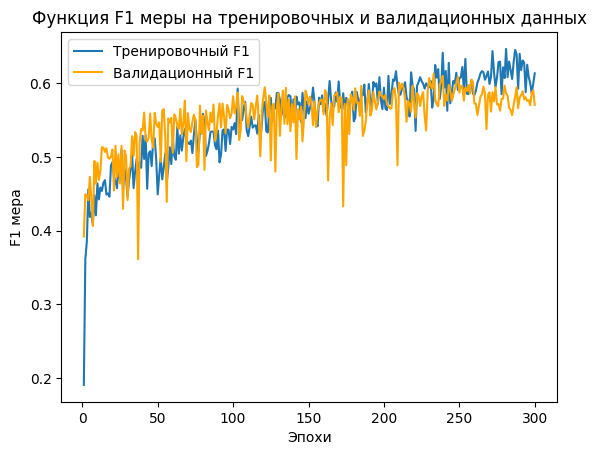

In [ ]:
import matplotlib.pyplot as plt
loss_function = history['f1_score']
val_loss_function = history['val_f1_score']
epochs = range(1,len(loss_function)+1)

plt.title('Функция F1 меры на тренировочных и валидационных данных')
plt.plot(epochs,loss_function,label='Тренировочный F1')
plt.plot(epochs,val_loss_function,color='orange',label='Валидационный F1')
plt.xlabel('Эпохи')
plt.ylabel('F1 мера')
plt.legend()
plt.show()

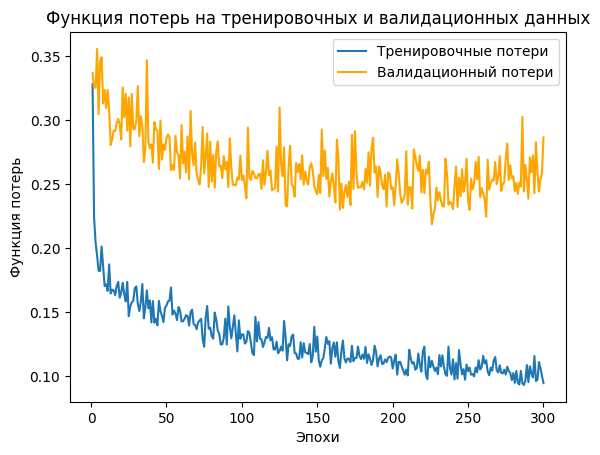

In [ ]:
loss_function = history['loss']
val_loss_function = history['val_loss']
epochs = range(1,len(loss_function)+1)

plt.title('Функция потерь на тренировочных и валидационных данных')
plt.plot(epochs,loss_function,label='Тренировочные потери')
plt.plot(epochs,val_loss_function,color='orange',label='Валидационный потери')
plt.xlabel('Эпохи')
plt.ylabel('Функция потерь')
plt.legend()
plt.show()

## FresUNet

In [ ]:
import matplotlib.pyplot as plt
test_image_trio=test_dataset.get_imgt_trio("lasvegas")
I1=test_image_trio[0]
I2=test_image_trio[1]
mask=test_image_trio[2]


I1_input = np.expand_dims(I1, axis=0)
I2_input = np.expand_dims(I2, axis=0)

In [ ]:
test_image_trio2=test_dataset.get_imgt_trio("chongqing")
I1_2=test_image_trio2[0]
I2_2=test_image_trio2[1]
mask_2=test_image_trio2[2]

#добавляем батч тк модель принимает батч
I1_input_2 = np.expand_dims(I1_2, axis=0)
I2_input_2 = np.expand_dims(I2_2, axis=0)

In [ ]:
test_image_trio3=test_dataset.get_imgt_trio("brasilia")
I1_3=test_image_trio3[0]
I2_3=test_image_trio3[1]
mask_3=test_image_trio3[2]

I1_input_3 = np.expand_dims(I1_3, axis=0)
I2_input_3 = np.expand_dims(I2_3, axis=0)

С косинусным расстоянием, аугментацией улучшенной и лики релу

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


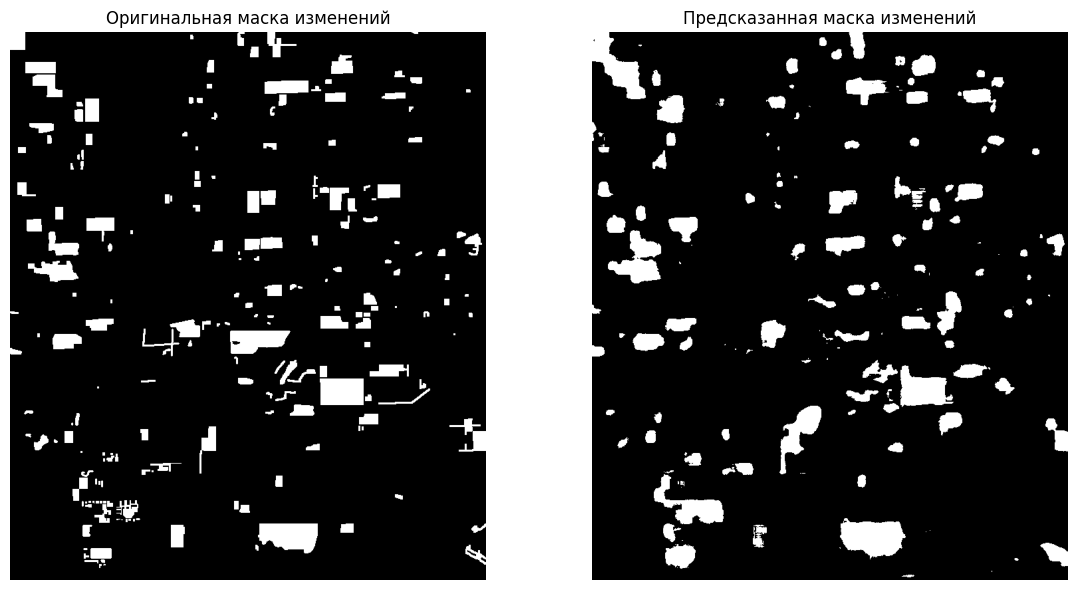

In [ ]:
prediction = net.predict([I1_input, I2_input])

# преобразуем в бинарную маску
# Аргумент axis=-1 означает, что argmax будет применяться по последней оси (классы)
predicted_mask = tf.argmax(prediction, axis=-1)
predicted_mask = predicted_mask[0].numpy().astype(bool) #удаление размерности батча и приведение к bool

# Для отладки визуализации: отобразим как оригинальную предсказанную маску, так и инвертированную
fig, axes = plt.subplots(1, 3, figsize=(18, 6)) # Увеличиваем количество сабплотов до 3

axes[0].imshow(mask, cmap='gray')
axes[0].set_title('Оригинальная маска изменений')
axes[0].axis('off')

axes[1].imshow(predicted_mask, cmap='gray')
axes[1].set_title('Предсказанная маска (как есть)')
axes[1].axis('off')

axes[2].imshow(~predicted_mask, cmap='gray') # Отображаем инвертированную маску
axes[2].set_title('Предсказанная маска (инвертированная)')
axes[2].axis('off')

plt.tight_layout()
plt.show()

Оригинальная

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


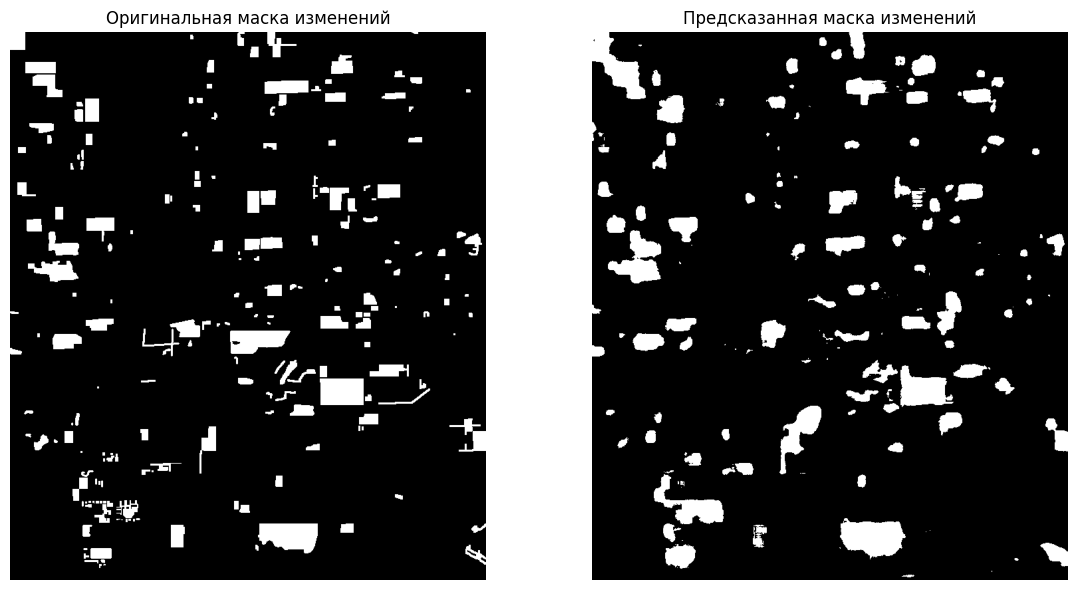

In [ ]:
prediction = net.predict([I1_input, I2_input])

# преобразуем в бинарную маску
# Аргумент axis=-1 означает, что argmax будет применяться по последней оси (классы)
predicted_mask = tf.argmax(prediction, axis=-1)
predicted_mask = predicted_mask[0].numpy().astype(bool) #удаление размерности батча и приведение к bool

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(mask, cmap='gray')
axes[0].set_title('Оригинальная маска изменений')
axes[0].axis('off')

axes[1].imshow(predicted_mask, cmap='gray')
axes[1].set_title('Предсказанная маска изменений')
axes[1].axis('off')

plt.tight_layout()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


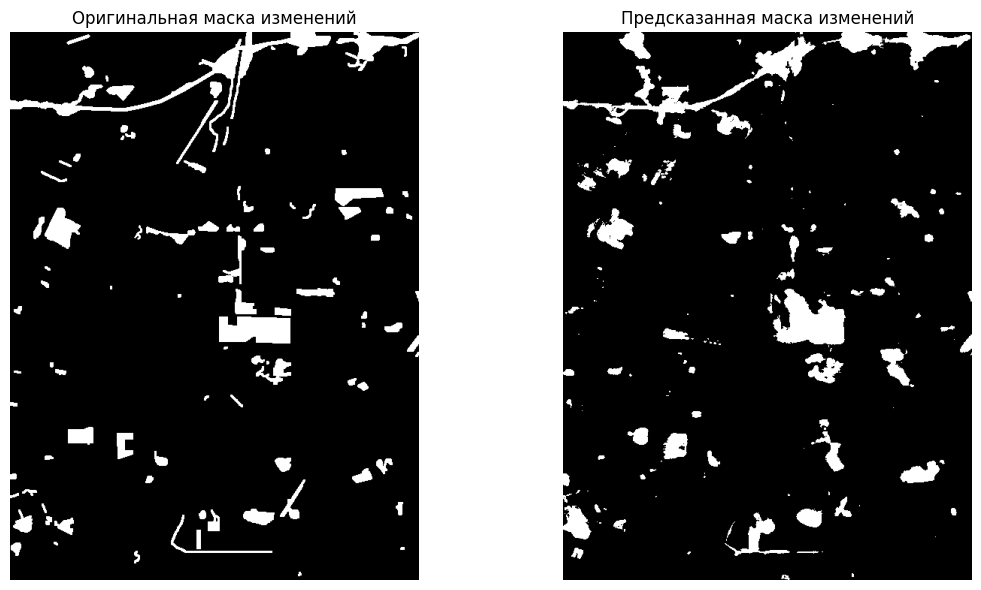

In [ ]:
prediction = net.predict([I1_input_2, I2_input_2])

predicted_mask = tf.argmax(prediction, axis=-1)
predicted_mask = predicted_mask[0].numpy().astype(bool)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(mask_2, cmap='gray')
axes[0].set_title('Оригинальная маска изменений')
axes[0].axis('off')

axes[1].imshow(predicted_mask, cmap='gray')
axes[1].set_title('Предсказанная маска изменений')
axes[1].axis('off')

plt.tight_layout()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 555ms/step


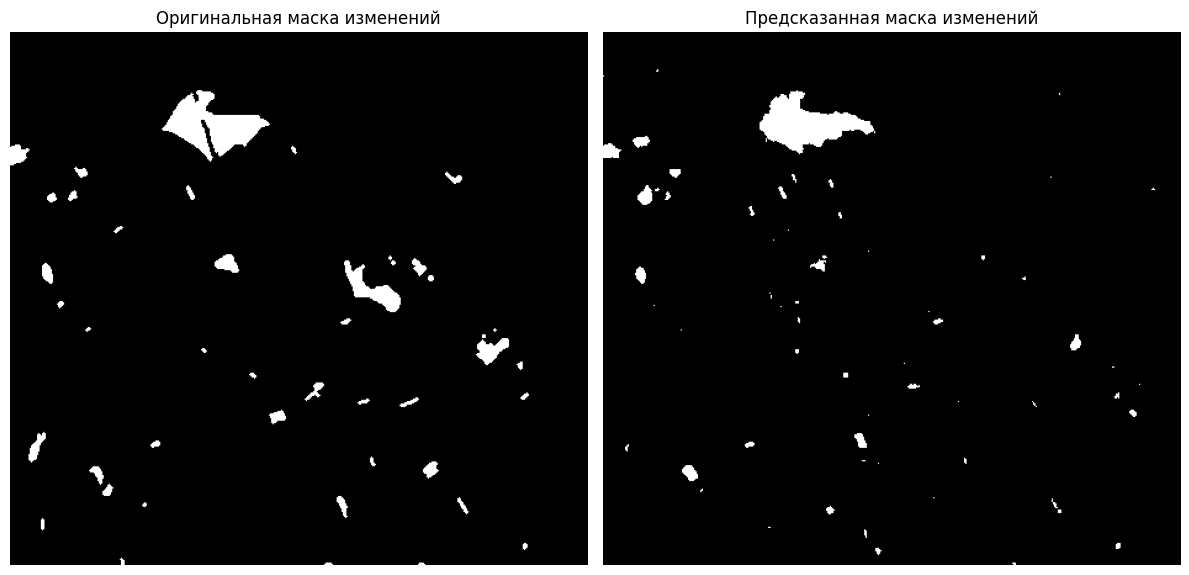

In [ ]:
prediction = net.predict([I1_input_3, I2_input_3])

predicted_mask = tf.argmax(prediction, axis=-1)
predicted_mask = predicted_mask[0].numpy().astype(bool)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(mask_3, cmap='gray')
axes[0].set_title('Оригинальная маска изменений')
axes[0].axis('off')

axes[1].imshow(predicted_mask, cmap='gray')
axes[1].set_title('Предсказанная маска изменений')
axes[1].axis('off')

plt.tight_layout()
plt.show()

С косинусным расстоянием, лики релу

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


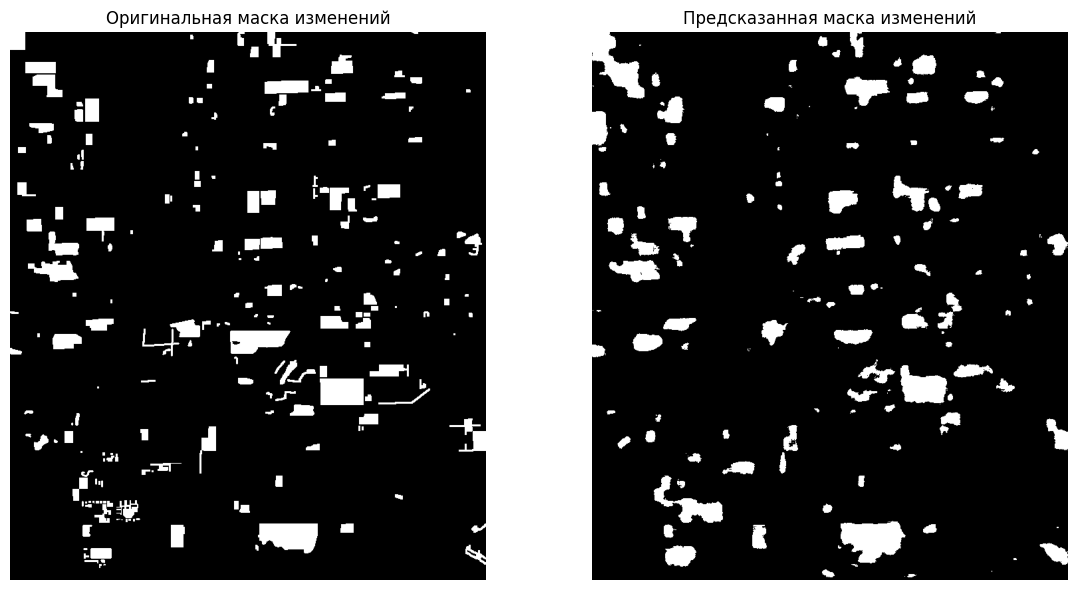

In [ ]:
prediction = net.predict([I1_input, I2_input])

predicted_mask = tf.argmax(prediction, axis=-1)
predicted_mask = predicted_mask[0].numpy().astype(bool)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(mask, cmap='gray')
axes[0].set_title('Оригинальная маска изменений')
axes[0].axis('off')

axes[1].imshow(predicted_mask, cmap='gray')
axes[1].set_title('Предсказанная маска изменений')
axes[1].axis('off')

plt.tight_layout()
plt.show()

Оригинальная модель

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


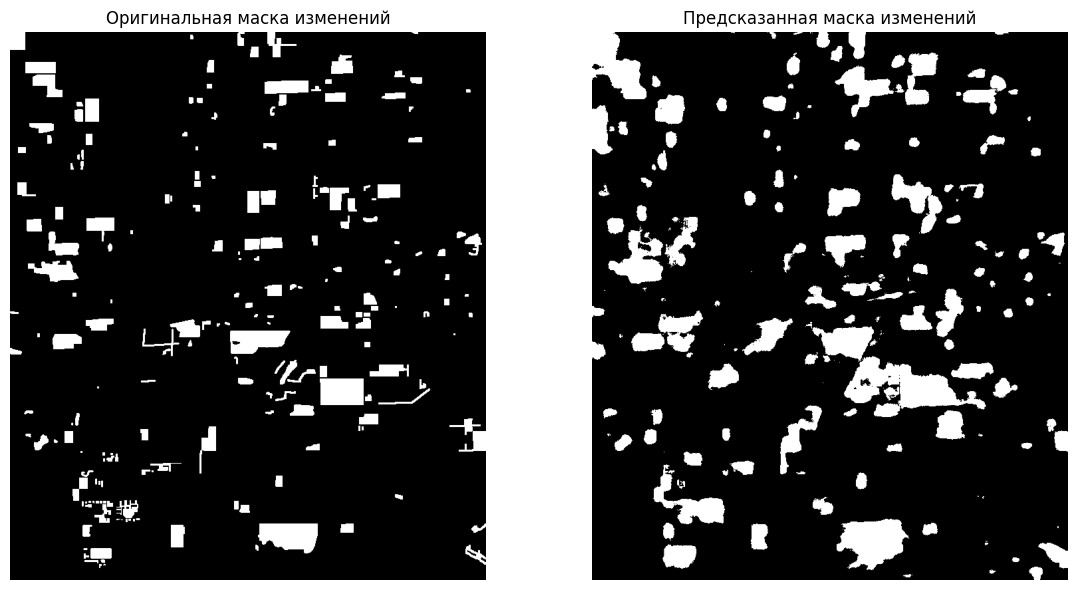

In [ ]:
prediction = net.predict([I1_input, I2_input])

predicted_mask = tf.argmax(prediction, axis=-1)
predicted_mask = predicted_mask[0].numpy().astype(bool)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(mask, cmap='gray')
axes[0].set_title('Оригинальная маска изменений')
axes[0].axis('off')

axes[1].imshow(predicted_mask, cmap='gray')
axes[1].set_title('Предсказанная маска изменений')
axes[1].axis('off')

plt.tight_layout()
plt.show()

недообучилась

## Unet

Оригинальный

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step


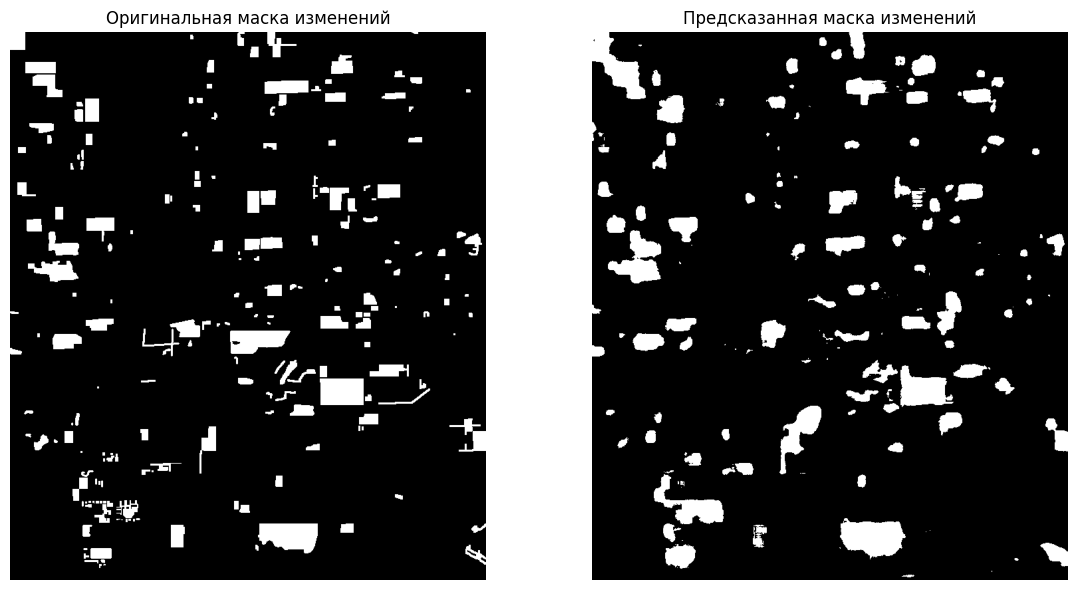

In [ ]:
prediction = net.predict([I1_input, I2_input])

predicted_mask = tf.argmax(prediction, axis=-1)
predicted_mask = predicted_mask[0].numpy().astype(bool)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(mask, cmap='gray')
axes[0].set_title('Оригинальная маска изменений')
axes[0].axis('off')

axes[1].imshow(predicted_mask, cmap='gray')
axes[1].set_title('Предсказанная маска изменений')
axes[1].axis('off')

plt.tight_layout()
plt.show()

# Другие датасеты

S2MTCP

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


data_a = np.load(path_to_test_dir2 + '21_a.npy')
data_b = np.load(path_to_test_dir2 + '21_b.npy')

print(data_a.shape)
print(data_b.shape)

rgb_image_a = data_a[:, :, [2, 1, 0]]
rgb_image_b = data_b[:, :, [2, 1, 0]]

rgb_image_c = rgb_image_a - rgb_image_b


print(rgb_image_c.shape)

I1_base = data_a[:, :, :13]
I2_base = data_b[:, :, :13]

I1_base_normalized = (I1_base - I1_base.mean(axis=(0, 1), keepdims=True)) / (I1_base.std(axis=(0, 1), keepdims=True) + 1e-6)
I2_base_normalized = (I2_base - I2_base.mean(axis=(0, 1), keepdims=True)) / (I2_base.std(axis=(0, 1), keepdims=True) + 1e-6)

H, W, C = I1_base_normalized.shape

reshaped_I1_pixels = I1_base_normalized.reshape(-1, C)
reshaped_I2_pixels = I2_base_normalized.reshape(-1, C)

pixel_cosine_distance = np.array([cosine_distance(reshaped_I1_pixels[i], reshaped_I2_pixels[i])
                                  for i in range(H * W)])
pixel_cosine_distance_map = pixel_cosine_distance.reshape(H, W, 1).astype(np.float32)

image_a_predict_with_cd = np.concatenate([I1_base_normalized, pixel_cosine_distance_map], axis=-1)

image_b_predict = I2_base_normalized

image_a_predict_expanded = np.expand_dims(image_a_predict_with_cd, axis=0)
image_b_predict_expanded = np.expand_dims(image_b_predict, axis=0)

prediction = net.predict([image_a_predict_expanded, image_b_predict_expanded])
predicted_mask = tf.argmax(prediction, axis=-1)
predicted_mask = predicted_mask[0].numpy().astype(bool)


rgb_image_a = (rgb_image_a - np.min(rgb_image_a)) / (np.max(rgb_image_a) - np.min(rgb_image_a))
rgb_image_b = (rgb_image_b - np.min(rgb_image_b)) / (np.max(rgb_image_b) - np.min(rgb_image_b))
rgb_image_c = (rgb_image_c - np.min(rgb_image_c)) / (np.max(rgb_image_c) - np.min(rgb_image_c))

(601, 819, 14)
(601, 819, 14)
(601, 819, 3)
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


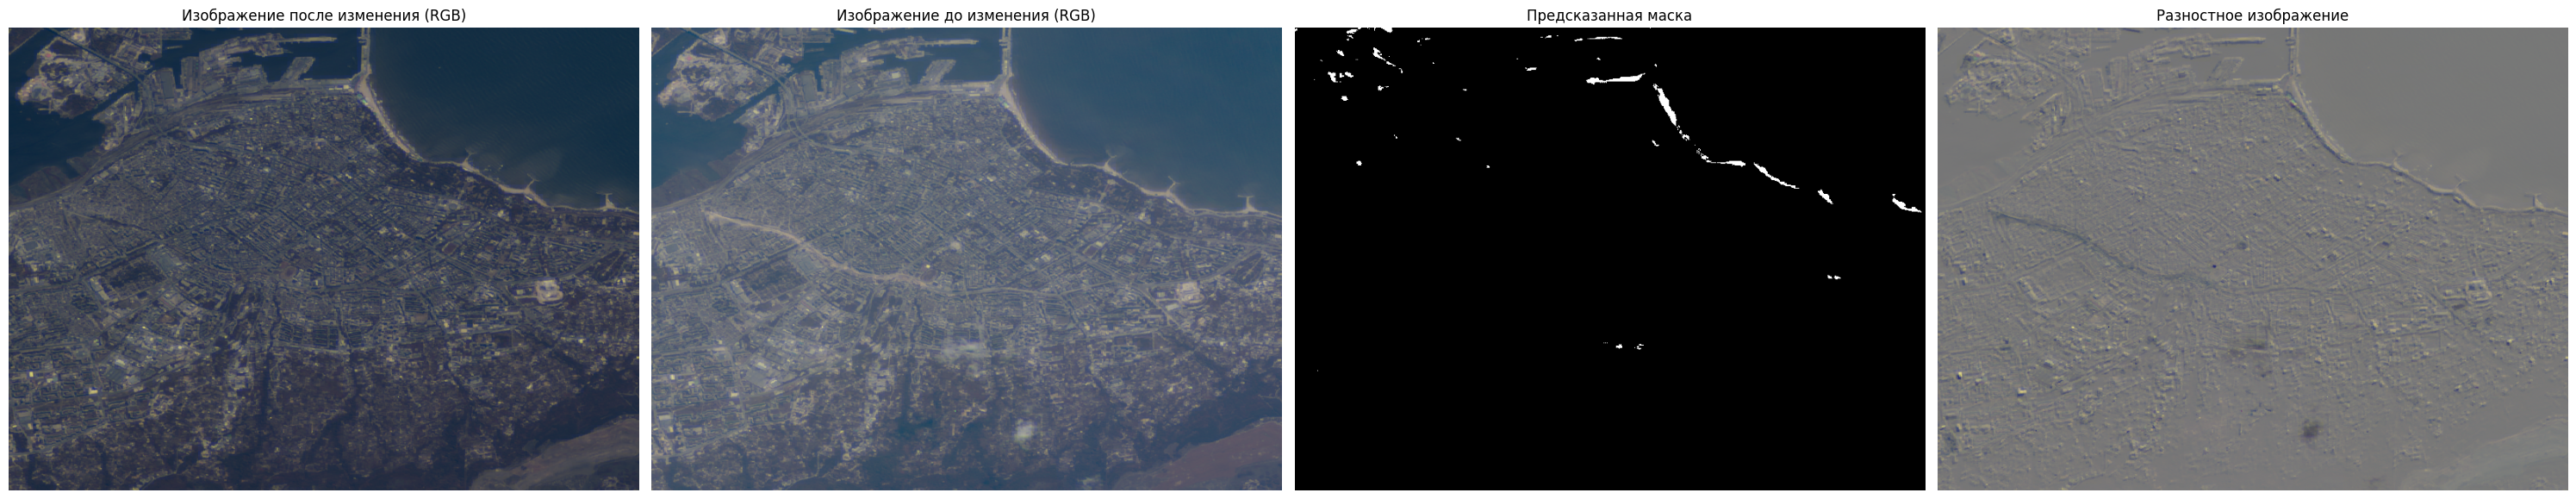

In [ ]:
plt.close()
fig, axes = plt.subplots(1, 4, figsize=(30, 20))

gamma = 0.6
rgb_image_a_display = rgb_image_a ** gamma
rgb_image_b_display = rgb_image_b ** 0.4
rgb_image_c_display = rgb_image_c

axes[0].imshow(rgb_image_a_display)
axes[0].set_title('Изображение после изменения (RGB)')
axes[0].axis('off')

axes[1].imshow(rgb_image_b_display)
axes[1].set_title('Изображение до изменения (RGB)')
axes[1].axis('off')

axes[2].imshow(predicted_mask, cmap='gray')
axes[2].set_title('Предсказанная маска')
axes[2].axis('off')

axes[3].imshow(rgb_image_c_display)
axes[3].set_title('Разностное изображение')
axes[3].axis('off')


plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


data_a = np.load(path_to_test_dir2 + '40_a.npy')
data_b = np.load(path_to_test_dir2 + '40_b.npy')

print(data_a.shape)
print(data_b.shape)

rgb_image_a = data_a[:, :, [2, 1, 0]]
rgb_image_b = data_b[:, :, [2, 1, 0]]

rgb_image_c = rgb_image_a - rgb_image_b


print(rgb_image_c.shape)

I1_base = data_a[:, :, :13]
I2_base = data_b[:, :, :13]

I1_base_normalized = (I1_base - I1_base.mean(axis=(0, 1), keepdims=True)) / (I1_base.std(axis=(0, 1), keepdims=True) + 1e-6)
I2_base_normalized = (I2_base - I2_base.mean(axis=(0, 1), keepdims=True)) / (I2_base.std(axis=(0, 1), keepdims=True) + 1e-6)

H, W, C = I1_base_normalized.shape

reshaped_I1_pixels = I1_base_normalized.reshape(-1, C)
reshaped_I2_pixels = I2_base_normalized.reshape(-1, C)

pixel_cosine_distance = np.array([cosine_distance(reshaped_I1_pixels[i], reshaped_I2_pixels[i])
                                  for i in range(H * W)])
pixel_cosine_distance_map = pixel_cosine_distance.reshape(H, W, 1).astype(np.float32)

image_a_predict_with_cd = np.concatenate([I1_base_normalized, pixel_cosine_distance_map], axis=-1)

image_b_predict = I2_base_normalized

image_a_predict_expanded = np.expand_dims(image_a_predict_with_cd, axis=0)
image_b_predict_expanded = np.expand_dims(image_b_predict, axis=0)

prediction = net.predict([image_a_predict_expanded, image_b_predict_expanded])
predicted_mask = tf.argmax(prediction, axis=-1)
predicted_mask = predicted_mask[0].numpy().astype(bool)


rgb_image_a = (rgb_image_a - np.min(rgb_image_a)) / (np.max(rgb_image_a) - np.min(rgb_image_a))
rgb_image_b = (rgb_image_b - np.min(rgb_image_b)) / (np.max(rgb_image_b) - np.min(rgb_image_b))
rgb_image_c = (rgb_image_c - np.min(rgb_image_c)) / (np.max(rgb_image_c) - np.min(rgb_image_c))

(601, 599, 14)
(601, 599, 14)
(601, 599, 3)
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 732ms/step


/tmp/ipykernel_761/3685470096.py:48: RuntimeWarning: invalid value encountered in divide
  rgb_image_c = (rgb_image_c - np.min(rgb_image_c)) / (np.max(rgb_image_c) - np.min(rgb_image_c))


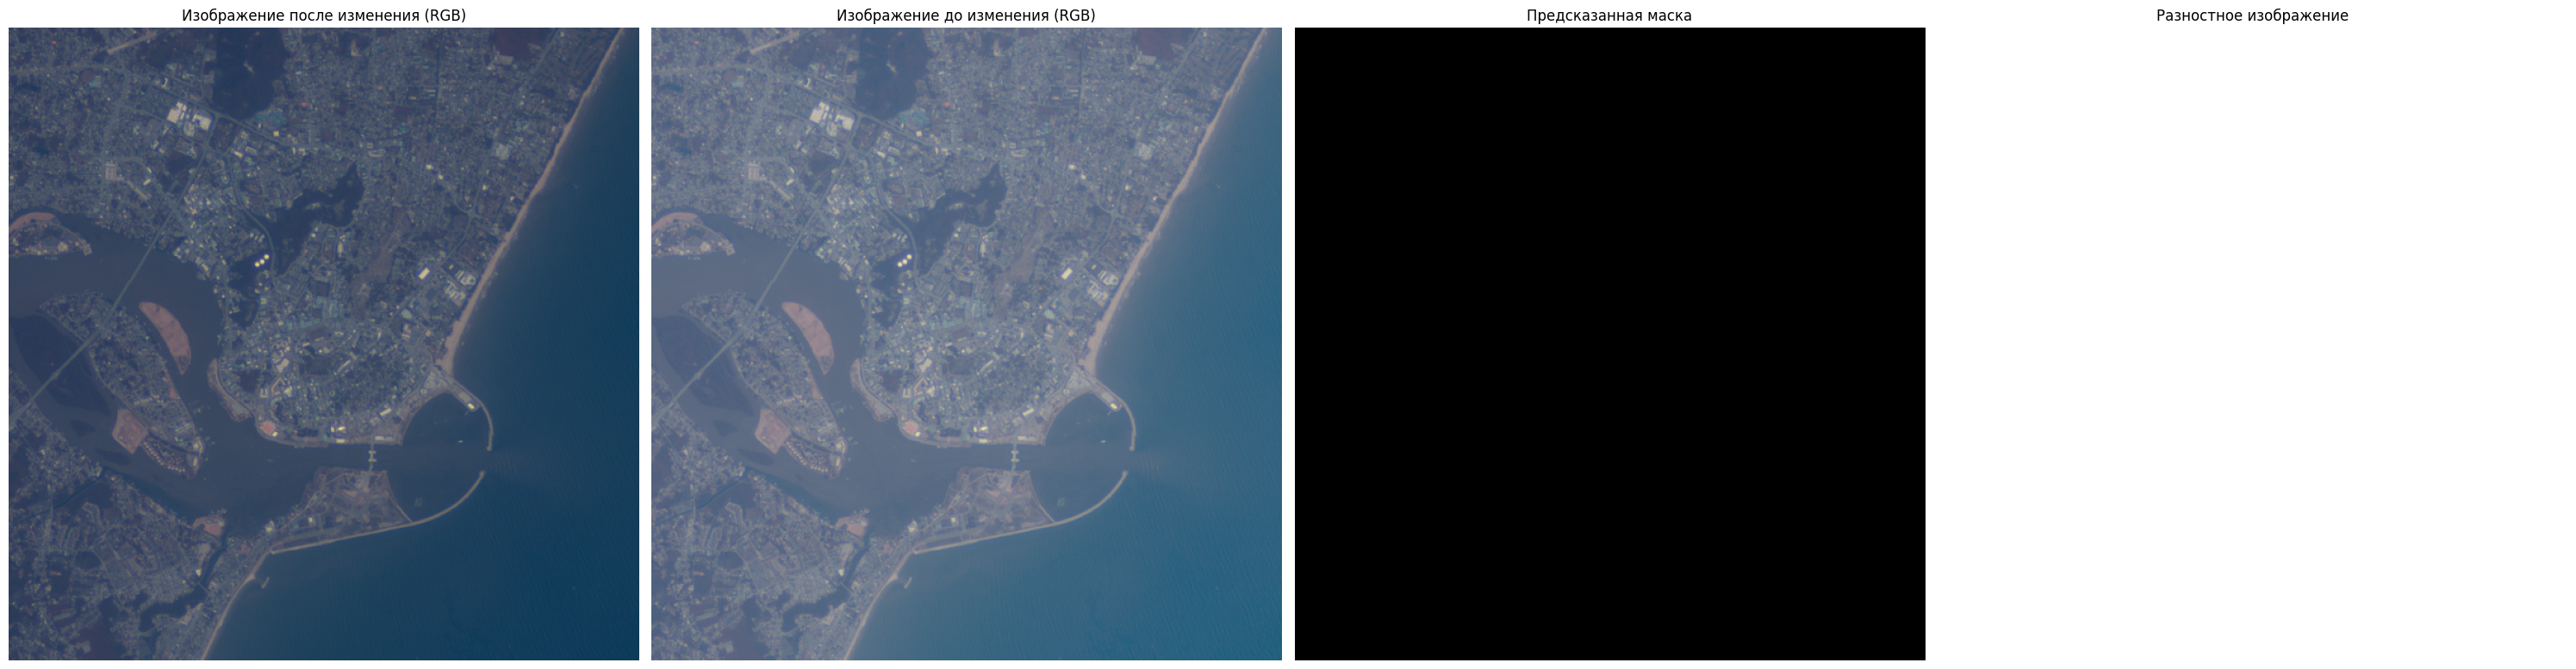

In [ ]:
plt.close()
fig, axes = plt.subplots(1, 4, figsize=(30, 20))

gamma = 0.6
rgb_image_a_display = rgb_image_a ** gamma
rgb_image_b_display = rgb_image_b ** 0.4
rgb_image_c_display = rgb_image_c

axes[0].imshow(rgb_image_a_display)
axes[0].set_title('Изображение после изменения (RGB)')
axes[0].axis('off')

axes[1].imshow(rgb_image_b_display)
axes[1].set_title('Изображение до изменения (RGB)')
axes[1].axis('off')

axes[2].imshow(predicted_mask, cmap='gray')
axes[2].set_title('Предсказанная маска')
axes[2].axis('off')

axes[3].imshow(rgb_image_c_display)
axes[3].set_title('Разностное изображение')
axes[3].axis('off')


plt.tight_layout()
plt.show()